In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
results = pd.read_csv("../reports/baseline_predictions.csv")

print("Prediction Results Loaded Successfully")

Prediction Results Loaded Successfully


C:\Users\user\AppData\Local\Temp\ipykernel_6748\3026312009.py:1: DtypeWarning: Columns (0: promo_event) have mixed types. Specify dtype option on import or set low_memory=False.
  results = pd.read_csv("../reports/baseline_predictions.csv")


In [3]:
results.head()

,date,sku_id,units_sold,revenue,unit_price,promo_flag,category,subcategory,launch_date,unit_cost,...,promo_event,on_hand_units,on_order_units,lead_time_days,reorder_point,day,day_of_week,quarter,year,Predicted_Units_Sold
0,2024-01-01,SKU001,16,3814.08,238.38,0,Appliances,General,2023-01-01,173,...,NaN,171.0,95.0,13.0,71.0,1,0,1,2024,14.24
1,2024-01-01,SKU002,9,943.65,104.85,0,Furniture,General,2023-01-01,72,...,NaN,78.0,59.0,5.0,29.0,1,0,1,2024,10.11
2,2024-01-01,SKU003,14,4658.92,332.78,0,Furniture,General,2023-01-01,183,...,NaN,135.0,86.0,15.0,74.0,1,0,1,2024,12.40
3,2024-01-01,SKU004,11,2825.35,256.85,0,Furniture,General,2023-01-01,161,...,NaN,207.0,11.0,15.0,20.0,1,0,1,2024,10.72
4,2024-01-01,SKU005,12,575.40,47.95,0,Furniture,General,2023-01-01,33,...,NaN,155.0,68.0,6.0,49.0,1,0,1,2024,10.77


In [4]:
results.info()

<class 'pandas.DataFrame'>
RangeIndex: 73000 entries, 0 to 72999
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  73000 non-null  str    
 1   sku_id                73000 non-null  str    
 2   units_sold            73000 non-null  int64  
 3   revenue               73000 non-null  float64
 4   unit_price            73000 non-null  float64
 5   promo_flag            73000 non-null  int64  
 6   category              73000 non-null  str    
 7   subcategory           73000 non-null  str    
 8   launch_date           73000 non-null  str    
 9   unit_cost             73000 non-null  int64  
 10  list_price            73000 non-null  float64
 11  week                  73000 non-null  int64  
 12  month                 73000 non-null  int64  
 13  season                73000 non-null  str    
 14  is_holiday            73000 non-null  int64  
 15  promo_event           1600 non

In [5]:
results.isnull().sum()

date                        0
sku_id                      0
units_sold                  0
revenue                     0
unit_price                  0
promo_flag                  0
category                    0
subcategory                 0
launch_date                 0
unit_cost                   0
list_price                  0
week                        0
month                       0
season                      0
is_holiday                  0
promo_event             71400
on_hand_units           63400
on_order_units          63400
lead_time_days          63400
reorder_point           63400
day                         0
day_of_week                 0
quarter                     0
year                        0
Predicted_Units_Sold        0
dtype: int64

In [6]:
results.describe()

,units_sold,revenue,unit_price,promo_flag,unit_cost,list_price,week,month,is_holiday,on_hand_units,on_order_units,lead_time_days,reorder_point,day,day_of_week,quarter,year,Predicted_Units_Sold
count,73000.000000,73000.000000,73000.000000,73000.000000,73000.000000,73000.000000,73000.000000,73000.000000,73000.000000,9600.000000,9600.000000,9600.000000,9600.000000,73000.000000,73000.000000,73000.000000,73000.0,73000.000000
mean,11.901219,2078.379005,175.070134,0.079918,107.645000,176.484950,26.430137,6.498630,0.142466,158.729375,49.728437,11.956250,49.877292,15.715068,2.991781,2.501370,2024.0,11.897831
std,4.226451,1398.413197,95.518430,0.271168,56.160593,96.137679,15.047013,3.443998,0.349530,81.126128,29.136575,5.489628,17.712634,8.787406,2.003419,1.116815,0.0,2.755417
min,0.000000,0.000000,14.980000,0.000000,10.000000,16.640000,1.000000,1.000000,0.000000,20.000000,0.000000,3.000000,20.000000,1.000000,0.000000,1.000000,2024.0,2.270000
25%,9.000000,951.800000,94.060000,0.000000,57.750000,94.780000,13.000000,4.000000,0.000000,87.000000,24.000000,7.000000,35.000000,8.000000,1.000000,2.000000,2024.0,10.140000
50%,12.000000,1799.560000,166.710000,0.000000,107.000000,167.980000,26.000000,7.000000,0.000000,159.000000,50.000000,12.000000,50.000000,16.000000,3.000000,3.000000,2024.0,11.710000
75%,15.000000,2961.340000,248.890000,0.000000,160.250000,253.352500,39.000000,9.000000,0.000000,229.000000,75.000000,17.000000,65.000000,23.000000,5.000000,3.000000,2024.0,13.460000
max,32.000000,10292.400000,381.200000,1.000000,200.000000,381.200000,52.000000,12.000000,1.000000,300.000000,100.000000,21.000000,80.000000,31.000000,6.000000,4.000000,2024.0,26.520000


In [7]:
mae = mean_absolute_error(
    results["Actual"],
    results["Predicted"]
)

print("Mean Absolute Error (MAE):", round(mae,3))

KeyError: 'Actual'

In [8]:
print(df.columns.tolist())

NameError: name 'df' is not defined

In [9]:
df.head()

NameError: name 'df' is not defined

In [10]:
results.head()

,date,sku_id,units_sold,revenue,unit_price,promo_flag,category,subcategory,launch_date,unit_cost,...,promo_event,on_hand_units,on_order_units,lead_time_days,reorder_point,day,day_of_week,quarter,year,Predicted_Units_Sold
0,2024-01-01,SKU001,16,3814.08,238.38,0,Appliances,General,2023-01-01,173,...,NaN,171.0,95.0,13.0,71.0,1,0,1,2024,14.24
1,2024-01-01,SKU002,9,943.65,104.85,0,Furniture,General,2023-01-01,72,...,NaN,78.0,59.0,5.0,29.0,1,0,1,2024,10.11
2,2024-01-01,SKU003,14,4658.92,332.78,0,Furniture,General,2023-01-01,183,...,NaN,135.0,86.0,15.0,74.0,1,0,1,2024,12.40
3,2024-01-01,SKU004,11,2825.35,256.85,0,Furniture,General,2023-01-01,161,...,NaN,207.0,11.0,15.0,20.0,1,0,1,2024,10.72
4,2024-01-01,SKU005,12,575.40,47.95,0,Furniture,General,2023-01-01,33,...,NaN,155.0,68.0,6.0,49.0,1,0,1,2024,10.77


In [11]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    results["units_sold"],
    results["Predicted_Units_Sold"]
)

print("Mean Absolute Error (MAE):", round(mae, 3))

Mean Absolute Error (MAE): 1.679


In [12]:
rmse = np.sqrt(
    mean_squared_error(
        results["units_sold"],
        results["Predicted_Units_Sold"]
    )
)

print("Root Mean Squared Error (RMSE):", round(rmse, 3))

Root Mean Squared Error (RMSE): 2.36


In [13]:
r2 = r2_score(
    results["units_sold"],
    results["Predicted_Units_Sold"]
)

print("R² Score:", round(r2, 3))

R² Score: 0.688


In [14]:
mape = (
    np.mean(
        np.abs(
            (
                results["units_sold"]
                -
                results["Predicted_Units_Sold"]
            )
            /
            results["units_sold"].replace(0,1)
        )
    )
) * 100

print("MAPE:", round(mape,2), "%")

MAPE: 21.37 %


In [15]:
metrics = pd.DataFrame({

    "Metric":[
        "MAE",
        "RMSE",
        "R2 Score",
        "MAPE (%)"
    ],

    "Value":[
        mae,
        rmse,
        r2,
        mape
    ]

})

metrics

,Metric,Value
0,MAE,1.678682
1,RMSE,2.360417
2,R2 Score,0.688088
3,MAPE (%),21.374626


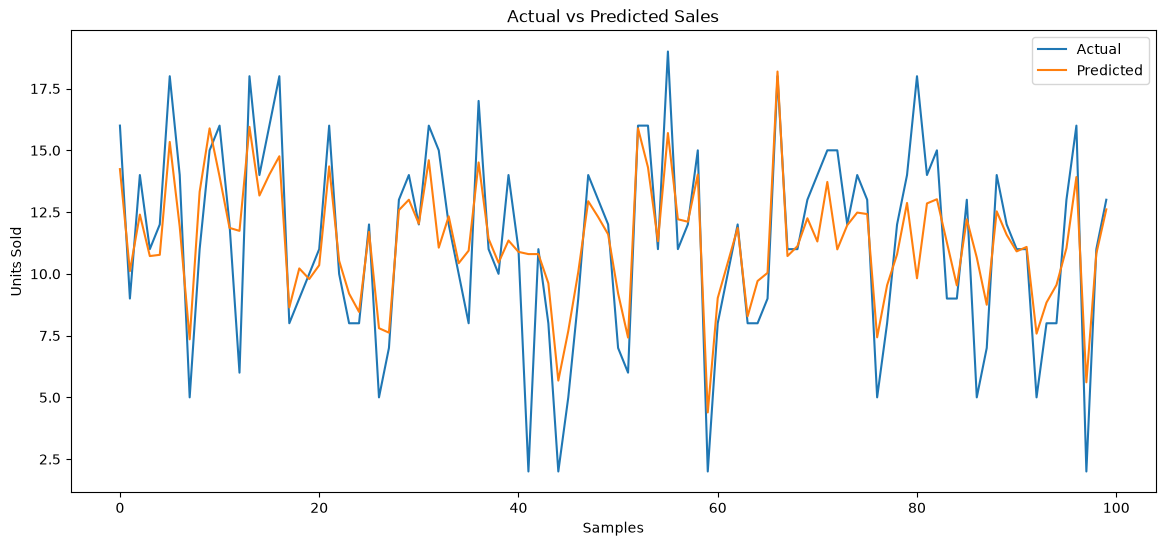

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    results["units_sold"][:100],
    label="Actual"
)

plt.plot(
    results["Predicted_Units_Sold"][:100],
    label="Predicted"
)

plt.title("Actual vs Predicted Sales")

plt.xlabel("Samples")

plt.ylabel("Units Sold")

plt.legend()

plt.show()

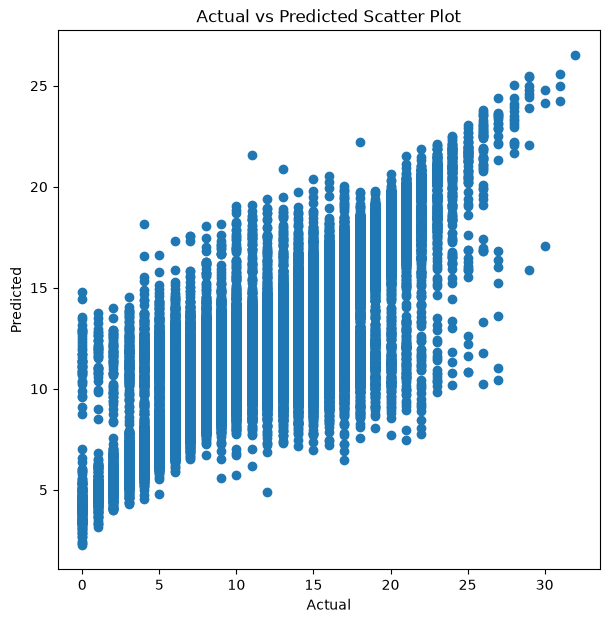

In [17]:
plt.figure(figsize=(7,7))

plt.scatter(
    results["units_sold"],
    results["Predicted_Units_Sold"]
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted Scatter Plot")

plt.show()

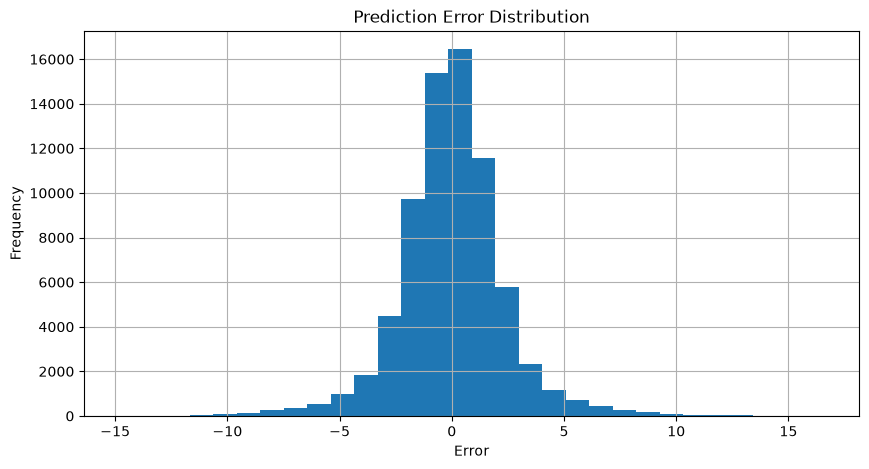

In [18]:
results["Error"] = (
    results["units_sold"]
    -
    results["Predicted_Units_Sold"]
)

results["Error"].hist(
    bins=30,
    figsize=(10,5)
)

plt.title("Prediction Error Distribution")

plt.xlabel("Error")

plt.ylabel("Frequency")

plt.show()

In [19]:
metrics.to_csv(
    "../reports/model_evaluation_metrics.csv",
    index=False
)

print("Evaluation Metrics Saved Successfully")

Evaluation Metrics Saved Successfully


In [20]:
print("="*60)
print("MODEL EVALUATION COMPLETED SUCCESSFULLY")
print("="*60)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")
print(f"MAPE : {mape:.2f}%")

MODEL EVALUATION COMPLETED SUCCESSFULLY
MAE  : 1.679
RMSE : 2.360
R²   : 0.688
MAPE : 21.37%
